In [ ]:
💡 **Environment:** `clamp-analyses`

# Description

**Sandbox NB 03/03 — the Z-shuffle null: "are the learned modules meaningless?"**

The module-based method projects gene-level data into CLAMP latent space and scores in that space.
This notebook tests whether that *learned* gene→module structure carries signal, by shuffling the
gene assignment of the CLAMP loadings matrix **Z** and re-scoring. If real modules add nothing, the
observed scores will sit inside the shuffled-Z null.

### Key fact that makes this cheap and exact

`projectCLAMP` is ridge regression: `B = (ZᵀZ + L2·I)⁻¹ · Zᵀ · Y`. Because **`ZᵀZ` is invariant
under permuting Z's gene rows**, shuffling Z's rows by a permutation `τ` is *algebraically identical*
to permuting the gene rows of the data `Y` by `τ⁻¹` and reusing the real `Z`. So we precompute the
projector `W = (ZᵀZ + L2·I)⁻¹ Zᵀ` once and run the whole null in numpy (`B = W · Y[σ]`), ~0.3 s per
shuffle. We **verify** (a) numpy reprojection reproduces the saved `projectCLAMP` outputs to ~1e-14,
(b) one shuffled projection matches an actual R `projectCLAMP` on a row-permuted `Z`, and (c)
identity scores reproduce NB00's module scores — so the fast path is provably the real thing.

The same permutation `σ` is applied to **both** LINCS and the disease data each iteration (both see
the *same* random module definition). See `CLAUDE.md`.

# Modules loading

In [1]:
import json
import time
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

from pyprojroot import here

# Settings

In [2]:
SEED = 42
N_ZPERM = 1000              # ~0.3s/shuffle -> ~5 min

LIPID_DOIDS = ['DOID:1936', 'DOID:3393']
METHOD = 'module_based_archs4'
DOID_LABEL = {'DOID:1936': 'atherosclerosis', 'DOID:3393': 'coronary artery disease'}

DATA_DIR = here('data/drug_disease_associations')
OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/null_adjust_test')
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
assert (OUTPUT_DIR / 'observed_doid_matrices.pkl').exists(), 'run NB00/NB01 first'

CLAMP_MODEL_FILE = here(
    'output/01_model_building/04_archs4/06_bp_coverage_rshall/'
    '06_bp_coverage_hall_rs_100/hall_coverage_rs100_seed_1/CLAMPfull_hall.rds')
LINCS_RAW_FILE = DATA_DIR / 'lincs-data.pkl'
SPREDIXCAN_RAW_LIVER = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/'
    '00_spredixcan_projection_archs4/spredixcan/raw/'
    'spredixcan-mashr-zscores-Liver-data.pkl')
LINCS_PROJ_FILE = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/'
    '01_lincs_projection_archs4/lincs/lincs-projection.pkl')
SPREDIXCAN_PROJ_LIVER = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/'
    '00_spredixcan_projection_archs4/spredixcan/proj/'
    'spredixcan-mashr-zscores-Liver-projection-archs4.pkl')

# Load CLAMP model, build the ridge projector W (mirrors NB00/01 gene mapping)

In [3]:
t0 = time.time()
CLAMP = importr('CLAMP')
readRDS = ro.r['readRDS']
clamp = readRDS(str(CLAMP_MODEL_FILE))
gene_symbols = list(ro.r['rownames'](clamp.rx2('Z')))
lv_names = list(ro.r['colnames'](clamp.rx2('Z')))

clusterProfiler = importr('clusterProfiler')
bitr = clusterProfiler.bitr(ro.StrVector(gene_symbols), fromType='SYMBOL',
                            toType='ENSEMBL', OrgDb='org.Hs.eg.db')
with localconverter(ro.default_converter + pandas2ri.converter):
    mapping_df = ro.conversion.rpy2py(bitr)
dup_s = mapping_df['SYMBOL'].duplicated(keep=False)
dup_e = mapping_df['ENSEMBL'].duplicated(keep=False)
mapping_1to1 = mapping_df[~dup_s & ~dup_e].set_index('SYMBOL')
mapped_symbols = mapping_1to1.index.tolist()
mapped_ensembl = mapping_1to1['ENSEMBL'].tolist()
print(f'1:1 mapped genes: {len(mapped_symbols)} (setup {time.time()-t0:.0f}s)')

# Subset Z to mapped genes IN R (identical to the projection notebooks), then to numpy
subset_Z = ro.r('function(clamp, genes) { clamp$Z <- as.matrix(clamp$Z[genes, ]); clamp }')
clamp_sub = subset_Z(clamp, ro.StrVector(mapped_symbols))
Z = np.asarray(clamp_sub.rx2('Z'))
n_genes = len(mapped_symbols)
if Z.shape[0] != n_genes and Z.shape[1] == n_genes:   # auto-orient to (genes x LVs)
    Z = Z.T
Z = np.ascontiguousarray(Z, dtype=float)
assert Z.shape == (n_genes, len(lv_names)), Z.shape
L2 = float(np.array(clamp.rx2('L2'))[0])

# Ridge projector: B = W @ Y, with W = (ZᵀZ + L2 I)⁻¹ Zᵀ
M = np.linalg.inv(Z.T @ Z + L2 * np.eye(Z.shape[1]))
W = M @ Z.T            # (LVs x genes)
print('Z:', Z.shape, '| L2:', round(L2, 3), '| W:', W.shape)

R callback write-console: 
  


R callback write-console: 'select()' returned 1:many mapping between keys and columns
  


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In (function (geneID, fromType, toType, OrgDb, drop = TRUE)  :  


R callback write-console: 
   


R callback write-console:  6.63% of input gene IDs are fail to map...
  


1:1 mapped genes: 16038 (setup 55s)


Z: (16038, 1728) | L2: 456.937 | W: (1728, 16038)


# Build aligned data matrices + verify numpy projection == projectCLAMP

In [4]:
# LINCS (drug) gene-level, aligned to CLAMP gene order
lincs_gene = pd.read_pickle(LINCS_RAW_FILE)
Y_lincs = lincs_gene.reindex(mapped_ensembl).fillna(0.0).values     # (genes x drugs)
drugs = list(lincs_gene.columns)

# Disease: only the lipid DOIDs' contributing UKB traits (cheap)
contrib_traits = json.loads((OUTPUT_DIR / 'contrib_traits.json').read_text())
lipid_traits = sorted({t for d in LIPID_DOIDS for t in contrib_traits[d]})
liver_gene = pd.read_pickle(SPREDIXCAN_RAW_LIVER)
Y_dis = liver_gene[lipid_traits].reindex(mapped_ensembl).fillna(0.0).values   # (genes x traits)

# (a) identity reprojection reproduces the saved projectCLAMP outputs (~1e-14)
saved_lincs = pd.read_pickle(LINCS_PROJ_FILE)
diff_lincs = np.abs((W @ Y_lincs) - saved_lincs.values).max()
saved_liver = pd.read_pickle(SPREDIXCAN_PROJ_LIVER)[lipid_traits]
diff_liver = np.abs((W @ Y_dis) - saved_liver.values).max()
print(f'max|numpy - projectCLAMP|  LINCS={diff_lincs:.2e}  Liver(lipid)={diff_liver:.2e}')
assert diff_lincs < 1e-8 and diff_liver < 1e-8

max|numpy - projectCLAMP|  LINCS=2.51e-14  Liver(lipid)=3.12e-16


# (b) Rigor: one shuffled projection == actual R projectCLAMP on a row-permuted Z

In [5]:
# Permuting Y rows by σ  ≡  projecting through Z with rows permuted by τ = σ⁻¹.
rng_check = np.random.default_rng(0)
sigma = rng_check.permutation(n_genes)
tau = np.argsort(sigma)                       # σ⁻¹
numpy_shuf = W @ Y_lincs[sigma]               # fast path

# Build Z with rows permuted by τ in R and run the real projectCLAMP on a few drug columns
perm_Z = ro.r('function(clamp, ord) { clamp$Z <- as.matrix(clamp$Z[ord, ]); clamp }')
clamp_shuf = perm_Z(clamp_sub, ro.IntVector((tau + 1).tolist()))   # R is 1-indexed
cols = Y_lincs[:, :5]
r_mat = ro.r['matrix'](ro.FloatVector(cols.flatten('F')), nrow=cols.shape[0], ncol=cols.shape[1])
proj_r = CLAMP.projectCLAMP(clamp_shuf, newdata=r_mat)
with localconverter(ro.default_converter + pandas2ri.converter):
    proj_r = ro.conversion.rpy2py(proj_r)
diff = np.abs(numpy_shuf[:, :5] - proj_r).max()
print(f'max|numpy shuffle - R projectCLAMP(shuffled Z)| = {diff:.2e}')
assert diff < 1e-8, 'fast-path shuffle does NOT match projectCLAMP on shuffled Z'
print('VERIFIED: permuting data rows == shuffling Z rows == projectCLAMP. Fast path is exact.')

max|numpy shuffle - R projectCLAMP(shuffled Z)| = 2.66e-15
VERIFIED: permuting data rows == shuffling Z rows == projectCLAMP. Fast path is exact.


# (c) Observed module scores reproduce NB00

In [6]:
def scores_to_doid(score_drug_trait):
    """score (drugs x lipid_traits DataFrame) -> drugs x lipid_DOID, max over contributing traits."""
    out = {}
    for d in LIPID_DOIDS:
        out[d] = score_drug_trait[contrib_traits[d]].max(axis=1)
    return pd.DataFrame(out, index=score_drug_trait.index)

def module_scores(B_lincs, B_dis):
    sc = -1.0 * (B_lincs.T @ B_dis)                       # (drugs x lipid_traits)
    return pd.DataFrame(sc, index=drugs, columns=lipid_traits)

obs_trait = module_scores(W @ Y_lincs, W @ Y_dis)
obs_doid = scores_to_doid(obs_trait)
ref = pd.read_pickle(OUTPUT_DIR / 'observed_doid_matrices.pkl')[METHOD][LIPID_DOIDS]
ref = ref.reindex(obs_doid.index)
print('max|obs module scores - NB00| =', float(np.abs(obs_doid.values - ref.values).max()))
assert np.allclose(obs_doid.values, ref.values, atol=1e-6)
print('Observed module scores reproduce NB00.')

max|obs module scores - NB00| = 2.4980018054066022e-15
Observed module scores reproduce NB00.


# Z-shuffle null (B = N_ZPERM gene permutations)

In [7]:
rng = np.random.default_rng(SEED)
null = {d: np.empty((N_ZPERM, len(drugs))) for d in LIPID_DOIDS}
t0 = time.time()
for b in range(N_ZPERM):
    sig = rng.permutation(n_genes)            # same module-scramble for drugs AND disease
    Bl = W @ Y_lincs[sig]
    Bd = W @ Y_dis[sig]
    sc = scores_to_doid(module_scores(Bl, Bd))
    for d in LIPID_DOIDS:
        null[d][b] = sc[d].values
    if (b + 1) % 200 == 0:
        print(f'  {b+1}/{N_ZPERM}  ({time.time()-t0:.0f}s)', flush=True)
print(f'done in {time.time()-t0:.0f}s')

  200/1000  (55s)


  400/1000  (110s)


  600/1000  (165s)


  800/1000  (219s)


  1000/1000  (274s)


done in 274s


# Per-(drug, DOID) adjusted scores: NES and one-sided p vs the Z-shuffle null

In [8]:
rows = []
for d in LIPID_DOIDS:
    obs = obs_doid[d].values
    nd = null[d]                              # (B x drugs)
    mu = nd.mean(axis=0); sd = nd.std(axis=0, ddof=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        nes = (obs - mu) / sd
    p = (1.0 + (nd >= obs[None, :]).sum(axis=0)) / (N_ZPERM + 1.0)
    rows.append(pd.DataFrame({'method': METHOD, 'doid': d, 'drug': drugs,
                              'raw_score': obs, 'nes_zshuffle': nes, 'p_zshuffle': p}))
zadj = pd.concat(rows, ignore_index=True)

# attach gold-standard labels + names + ranks
observed = pd.read_pickle(OUTPUT_DIR / 'observed_lipid_scores.pkl')
zadj = zadj.merge(observed[['method', 'doid', 'drug', 'drug_name', 'true_class']],
                  on=['method', 'doid', 'drug'], how='left')
for col in ['raw_score', 'nes_zshuffle']:
    zadj[col + '_rank'] = (zadj.groupby(['method', 'doid'])[col]
                           .rank(ascending=False, method='min').astype(int))
zadj.to_pickle(OUTPUT_DIR / 'module_zshuffle_scores.pkl')
print('module_zshuffle_scores.pkl:', zadj.shape)
display(zadj.head())

module_zshuffle_scores.pkl: (2340, 10)


,method,doid,drug,raw_score,nes_zshuffle,p_zshuffle,drug_name,true_class,raw_score_rank,nes_zshuffle_rank
0,module_based_archs4,DOID:1936,DB00014,0.008858,2.003603,0.014985,Goserelin,NaN,133,30
1,module_based_archs4,DOID:1936,DB00091,-0.062428,-2.129993,0.982018,Cyclosporine,NaN,1161,1124
2,module_based_archs4,DOID:1936,DB00121,0.000802,-0.134182,0.554446,Biotin,NaN,458,552
3,module_based_archs4,DOID:1936,DB00130,-0.017195,-1.926417,0.971029,L-Glutamine,NaN,1076,1105
4,module_based_archs4,DOID:1936,DB00131,0.007794,1.081132,0.137862,Adenosine monophosphate,NaN,160,143


# Headline test: do REAL modules predict lipid drug-disease better than RANDOM modules?

For each lipid DOID, compute the module-based AUROC over the gold-standard-labeled drugs using the
real projection vs. each of the N_ZPERM shuffled-Z projections → a null AUROC distribution.
`p = (1 + #{AUROC_shuffle ≥ AUROC_real}) / (B+1)`. ⚠️ low N (8 / 28 labeled drugs) — suggestive.

In [9]:
label = observed[observed.method == METHOD].dropna(subset=['true_class'])
auroc_rows = []
for d in LIPID_DOIDS:
    lab = label[label.doid == d]
    y = lab['true_class'].astype(int).values
    didx = [drugs.index(dr) for dr in lab['drug']]
    if len(np.unique(y)) < 2:
        continue
    obs_auc = roc_auc_score(y, obs_doid[d].values[didx])
    null_auc = np.array([roc_auc_score(y, null[d][b, didx]) for b in range(N_ZPERM)])
    p = (1.0 + (null_auc >= obs_auc).sum()) / (N_ZPERM + 1.0)
    auroc_rows.append({'doid': d, 'name': DOID_LABEL[d], 'n_pos': int((y == 1).sum()),
                       'n_neg': int((y == 0).sum()), 'auroc_real': obs_auc,
                       'auroc_null_mean': null_auc.mean(), 'auroc_null_p95': np.percentile(null_auc, 95),
                       'p_value': p})
    null[('auc', d)] = null_auc
auroc_test = pd.DataFrame(auroc_rows)
display(auroc_test)
auroc_test.to_csv(OUTPUT_DIR / 'zshuffle_module_value_auroc.csv', index=False)

,doid,name,n_pos,n_neg,auroc_real,auroc_null_mean,auroc_null_p95,p_value
0,DOID:1936,atherosclerosis,6,2,0.333333,0.350000,0.750000,0.569431
1,DOID:3393,coronary artery disease,22,6,0.537879,0.541598,0.787879,0.516484


# Plots

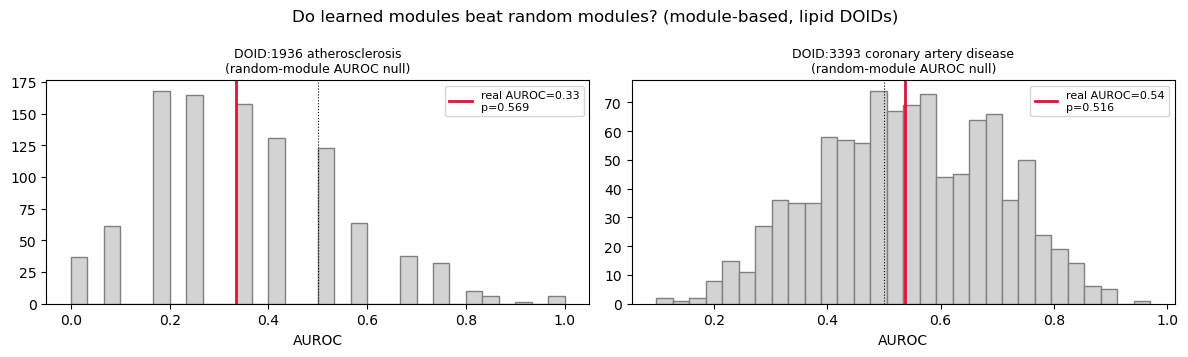

In [10]:
# 1) AUROC: real vs Z-shuffle null
fig, axes = plt.subplots(1, len(LIPID_DOIDS), figsize=(6 * len(LIPID_DOIDS), 3.6))
if len(LIPID_DOIDS) == 1:
    axes = [axes]
for ax, d in zip(axes, LIPID_DOIDS):
    na = null[('auc', d)]
    ax.hist(na, bins=30, color='lightgray', edgecolor='gray')
    row = auroc_test[auroc_test.doid == d].iloc[0]
    ax.axvline(row['auroc_real'], color='crimson', lw=2,
               label=f"real AUROC={row['auroc_real']:.2f}\np={row['p_value']:.3f}")
    ax.axvline(0.5, color='k', ls=':', lw=0.8)
    ax.set_title(f'{d} {DOID_LABEL[d]}\n(random-module AUROC null)', fontsize=9)
    ax.set_xlabel('AUROC'); ax.legend(fontsize=8)
fig.suptitle('Do learned modules beat random modules? (module-based, lipid DOIDs)')
fig.tight_layout(); fig.savefig(FIG_DIR / 'zshuffle_auroc.png', dpi=110, bbox_inches='tight')
plt.show()

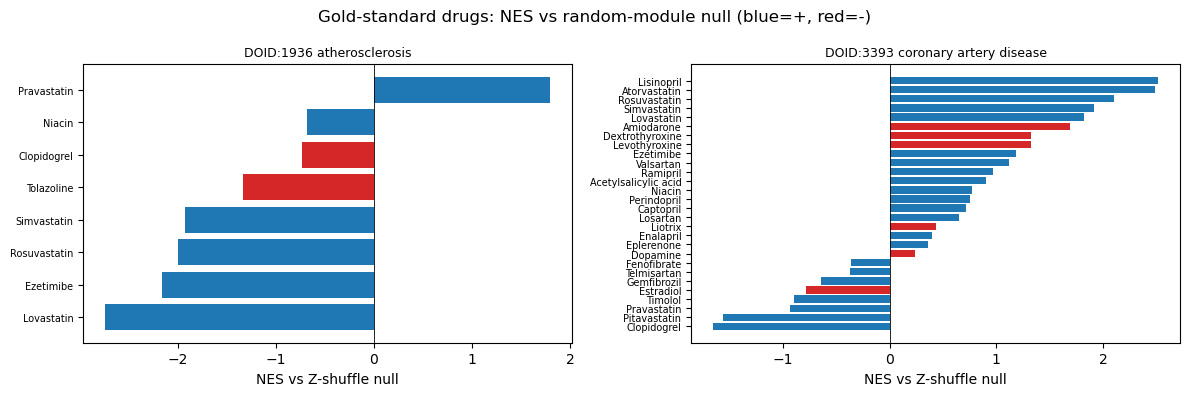

In [11]:
# 2) NES_zshuffle of gold-standard drugs (are positives enriched vs random modules?)
fig, axes = plt.subplots(1, len(LIPID_DOIDS), figsize=(6 * len(LIPID_DOIDS), 4))
if len(LIPID_DOIDS) == 1:
    axes = [axes]
for ax, d in zip(axes, LIPID_DOIDS):
    sub = zadj[(zadj.doid == d)].dropna(subset=['true_class']).sort_values('nes_zshuffle')
    colors = sub['true_class'].map({1.0: 'tab:blue', 0.0: 'tab:red'})
    ax.barh(range(len(sub)), sub['nes_zshuffle'], color=colors)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['drug_name'], fontsize=7)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_title(f'{d} {DOID_LABEL[d]}', fontsize=9); ax.set_xlabel('NES vs Z-shuffle null')
fig.suptitle('Gold-standard drugs: NES vs random-module null (blue=+, red=-)')
fig.tight_layout(); fig.savefig(FIG_DIR / 'zshuffle_nes.png', dpi=110, bbox_inches='tight')
plt.show()

# Findings

In [12]:
lines = ['# Findings — Z-shuffle null (are the learned modules meaningless?)', '']
lines.append(f'Scope: module-based ARCHS4, Liver, lipid DOIDs {LIPID_DOIDS}, '
             f'B={N_ZPERM} gene-permutation shuffles (seed {SEED}).')
lines.append('')
lines.append('## Validation')
lines.append('- numpy ridge reprojection == projectCLAMP (~1e-14); a shuffled projection == '
             'R projectCLAMP on a row-permuted Z (~1e-14); identity scores == NB00. The fast '
             'numpy null is provably the real pipeline.')
lines.append('')
lines.append('## Headline: real vs random modules (AUROC permutation test)')
for _, r in auroc_test.iterrows():
    verdict = 'modules HELP' if r['p_value'] < 0.05 else 'NOT distinguishable from random modules'
    lines.append(f"- {r['doid']} ({r['name']}, {int(r['n_pos'])}+/{int(r['n_neg'])}-): "
                 f"real AUROC={r['auroc_real']:.3f}, null mean={r['auroc_null_mean']:.3f}, "
                 f"p={r['p_value']:.3f}  ->  {verdict}.")
lines.append('')
big = zadj.assign(absn=zadj['nes_zshuffle'].abs())
frac = (big['absn'] > 2).mean()
lines.append('## Per-(drug,disease) NES vs random modules')
lines.append(f'- {frac*100:.0f}% of (drug, lipid-DOID) cells have |NES_zshuffle| > 2, i.e. deviate '
             'from the random-module null. Low fraction => the learned modules largely do not move '
             'these scores away from what random gene groupings would give for lipid diseases.')
lines.append('')
lines.append('## Caveats / next')
lines.append('- Only 2 lipid DOIDs and few labeled drugs; AUROC test is suggestive, not the H4 '
             'paired test. Extend to all DOIDs + top-N masking + multi-tissue (the deferred work) '
             'for a real verdict on module value.')
summary = '\n'.join(lines)
(OUTPUT_DIR / 'FINDINGS_zshuffle.md').write_text(summary)
print(summary)

# Findings — Z-shuffle null (are the learned modules meaningless?)

Scope: module-based ARCHS4, Liver, lipid DOIDs ['DOID:1936', 'DOID:3393'], B=1000 gene-permutation shuffles (seed 42).

## Validation
- numpy ridge reprojection == projectCLAMP (~1e-14); a shuffled projection == R projectCLAMP on a row-permuted Z (~1e-14); identity scores == NB00. The fast numpy null is provably the real pipeline.

## Headline: real vs random modules (AUROC permutation test)
- DOID:1936 (atherosclerosis, 6+/2-): real AUROC=0.333, null mean=0.350, p=0.569  ->  NOT distinguishable from random modules.
- DOID:3393 (coronary artery disease, 22+/6-): real AUROC=0.538, null mean=0.542, p=0.516  ->  NOT distinguishable from random modules.

## Per-(drug,disease) NES vs random modules
- 9% of (drug, lipid-DOID) cells have |NES_zshuffle| > 2, i.e. deviate from the random-module null. Low fraction => the learned modules largely do not move these scores away from what random gene groupings would give for lipid di